# 📊 EDA (Exploratory Data Analysis) - EventZilla - Version Améliorée

## 🎯 Objectifs de cette analyse

Ce notebook effectue une **analyse exploratoire approfondie** des données EventZilla pour :

1. **Décrire chaque fichier de données** : Structure, colonnes, lignes, types de données
2. **Évaluer la qualité des données** : Valeurs manquantes, doublons, valeurs aberrantes
3. **Décider comment gérer les problèmes de qualité** : Stratégies de traitement par fichier
4. **Analyser les relations entre fichiers** : Intégrité référentielle et corrélations
5. **Visualisations exploratoires et interprétations métier** : Graphiques de distribution et interprétations alignées sur DataMarketingRanimFinal (réservations, conversion, panier moyen, CAC, satisfaction)

## 📁 Données analysées

Tous les fichiers CSV du dossier `data_original/` (données originales EventZilla) :
- `BENEFICIARY.csv` : Bénéficiaires (clients)
- `CATEGORY.csv` : Catégories d'événements
- `SUBCATEGORY.csv` : Sous-catégories
- `SERVICE.csv` : Services proposés
- `PROVIDER.csv` : Prestataires
- `EVENT.csv` : Événements
- `RESERVATION.csv` : Réservations
- `EVALUATION.csv` : Évaluations des services
- `COMPLAINT.csv` : Réclamations
- `VISITORS.csv` : Trafic visiteurs
- `MARKETING_SPEND.csv` : Dépenses marketing

## 📈 Structure de l'analyse

1. **Configuration et chargement** : Import des librairies et chargement des données
2. **Description détaillée par fichier** : Structure, colonnes, types, dimensions
3. **Analyse de qualité par fichier** : Valeurs manquantes, doublons, valeurs aberrantes
4. **Décisions de gestion** : Comment traiter les problèmes identifiés
5. **Relations entre fichiers** : Intégrité référentielle et matrice de corrélation
6. **Visualisations et interprétations métier** : Distributions, KPIs et objectifs (DataMarketingRanimFinal)
7. **Cardinalités et relations** : Chiffres clés par relation logique
8. **Résumé et conclusions** : Synthèse et recommandations


In [1]:
# Import des librairies nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import os

warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Configuration des pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

print("✅ Librairies importées avec succès")
print(f"📅 Date d'analyse : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


✅ Librairies importées avec succès
📅 Date d'analyse : 2026-02-09 00:10:08


## 1. Configuration et Chargement des Données


In [2]:
# Configuration des chemins (data_original = fichiers CSV EventZilla d'origine)
DATA_CSV_DIR = 'data_original'
if not os.path.exists(DATA_CSV_DIR):
    DATA_CSV_DIR = os.path.join(os.path.dirname(os.getcwd()), 'data_original') if os.path.basename(os.getcwd()) == 'EDA' else 'data csv'

def read_csv_safe(filepath, sep=';', encodings=['utf-8', 'latin1', 'iso-8859-1', 'windows-1252']):
    """Charge un CSV en essayant plusieurs encodages"""
    for encoding in encodings:
        try:
            df = pd.read_csv(filepath, sep=sep, encoding=encoding, low_memory=False)
            print(f"   ✅ {os.path.basename(filepath)} chargé ({encoding})")
            return df
        except (UnicodeDecodeError, pd.errors.EmptyDataError):
            continue
    raise ValueError(f"Impossible de charger {filepath} avec les encodages testés")

# Liste des fichiers CSV
csv_files = {
    'beneficiary': 'BENEFICIARY.csv',
    'category': 'CATEGORY.csv',
    'subcategory': 'SUBCATEGORY.csv',
    'service': 'SERVICE.csv',
    'provider': 'PROVIDER.csv',
    'event': 'EVENT.csv',
    'reservation': 'RESERVATION.csv',
    'evaluation': 'EVALUATION.csv',
    'complaint': 'COMPLAINT.csv',
    'visitors': 'VISITORS.csv',
    'marketing_spend': 'MARKETING_SPEND.csv'
}

# Chargement de tous les fichiers
print("📂 Chargement des données...\n")
dataframes = {}

for name, filename in csv_files.items():
    filepath = os.path.join(DATA_CSV_DIR, filename)
    if os.path.exists(filepath):
        dataframes[name] = read_csv_safe(filepath)
    else:
        print(f"   ⚠️  {filename} introuvable")

print(f"\n✅ {len(dataframes)} fichiers chargés avec succès")


📂 Chargement des données...

   ✅ BENEFICIARY.csv chargé (utf-8)
   ✅ CATEGORY.csv chargé (utf-8)
   ✅ SUBCATEGORY.csv chargé (utf-8)
   ✅ SERVICE.csv chargé (utf-8)
   ✅ PROVIDER.csv chargé (latin1)
   ✅ EVENT.csv chargé (utf-8)
   ✅ RESERVATION.csv chargé (utf-8)
   ✅ EVALUATION.csv chargé (utf-8)
   ✅ COMPLAINT.csv chargé (utf-8)
   ✅ VISITORS.csv chargé (utf-8)
   ✅ MARKETING_SPEND.csv chargé (utf-8)

✅ 11 fichiers chargés avec succès


## 2. Description Détaillée de Chaque Fichier

### 2.1. Description des Colonnes par Fichier

#### 📋 BENEFICIARY.csv
- **id_beneficiary** (int) : Identifiant unique du bénéficiaire (client qui souhaite organiser un événement)
- **first_name** (string) : Prénom du bénéficiaire
- **last_name** (string) : Nom de famille du bénéficiaire (valeurs manquantes : aucune info dans email ni dans les autres fichiers → correction : "Not found")
- **email** (string) : Adresse email du bénéficiaire pour les communications (valeurs manquantes : ne pas remplir par concaténation first+last ; correction : "Not found")
- **phone** (string) : Numéro de téléphone du bénéficiaire (manquant ou aberrant si ≤4 chiffres ou négatif → correction : "00 000 000"). Voir indicateurs : bénéficiaires sans email ni phone, et numéros aberrants.

#### 📋 CATEGORY.csv
- **id_category** (int) : Identifiant unique de la catégorie d'événement
- **name** (string) : Nom de la catégorie (ex: Wedding, Corporate, Birthday)

#### 📋 SUBCATEGORY.csv
- **id_subcategory** (int) : Identifiant unique de la sous-catégorie de service
- **name** (string) : Nom de la sous-catégorie (ex: Venue, Catering, Entertainment, Decoration, Photography, DJ)
- **id_category** (int) : Référence vers la catégorie parente (clé étrangère)

#### 📋 SERVICE.csv
- **id_service** (int) : Identifiant unique du service proposé
- **price** (float) : Prix du service en TND (Tunisian Dinar)
- **description** (string) : Description détaillée du service proposé
- **id_provider** (int) : Référence vers le prestataire qui propose ce service (clé étrangère)
- **id_subcategory** (int) : Référence vers la sous-catégorie du service (clé étrangère)
- **title** (string) : Titre/nom du service (ex: Brand Activation Events). Les valeurs "#VALEUR!" sont le défaut pour les services sans titre.

#### 📋 PROVIDER.csv
- **id_provider** (int) : Identifiant unique du prestataire de service
- **name** (string) : Nom de l'entreprise ou du prestataire
- **service_type** (string) : Type de service principal proposé (ex: Decoration, Photography, DJ, Catering)
- **email** (string) : Adresse email du prestataire pour les communications
- **phone** (string) : Numéro de téléphone du prestataire
- **city** (string) : Ville où le prestataire est localisé

#### 📋 EVENT.csv
- **id_event** (int) : Identifiant unique de l'événement organisé
- **title** (string) : Titre ou description courte de l'événement
- **event_date** (datetime) : Date et heure prévues pour l'événement
- **budget** (float) : Budget alloué pour l'événement en TND
- **type** (string) : Type d'événement (ex: Birthday, Private Party, Wedding, Corporate Event)
- **id_beneficiary** (int) : Référence vers le bénéficiaire qui organise l'événement (clé étrangère)

#### 📋 RESERVATION.csv
- **id_reservation** (int) : Identifiant unique de la réservation de service
- **id_service** (int) : Référence vers le service réservé (clé étrangère)
- **id_event** (int) : Référence vers l'événement pour lequel le service est réservé (clé étrangère)
- **reservation_date** (datetime) : Date et heure de la réservation
- **status** (string) : Statut de la réservation (confirmed, pending, cancelled)
- **final_price** (float) : Prix final payé pour le service en TND

#### 📋 EVALUATION.csv
- **id_evaluation** (int) : Identifiant unique de l'évaluation
- **id_reservation** (int) : Référence vers la réservation évaluée (clé étrangère)
- **rating** (int) : Note attribuée au service (généralement de 1 à 5 étoiles)
- **comment** (string) : Commentaire textuel optionnel sur le service reçu

#### 📋 COMPLAINT.csv
- **id_complaint** (int) : Identifiant unique de la réclamation
- **description** (string) : Description détaillée de la réclamation
- **status** (string) : Statut de la réclamation (open, closed)
- **id_beneficiary** (int) : Référence vers le bénéficiaire qui a fait la réclamation (clé étrangère)
- **id_provider** (int) : Référence vers le prestataire concerné par la réclamation (clé étrangère)
- **subject** (string) : Sujet/catégorie de la réclamation (ex: Service Quality, Late Delivery, Billing Issue, Product Defect)

#### 📋 VISITORS.csv
- **id** (int) : Identifiant unique de l'enregistrement
- **date** (datetime) : Date de l'enregistrement du trafic (remarque : vérifier qu'aucune date ne doit être dupliquée)
- **visitors** (int) : Nombre de visiteurs uniques sur la plateforme pour cette date
- **reservations** (int) : Nombre de réservations effectuées ce jour-là

#### 📋 MARKETING_SPEND.csv
- **id** (int) : Identifiant unique de l'enregistrement
- **month** (string) : Mois de la dépense marketing (format YYYY-MM)
- **marketing_spend** (float) : Montant dépensé en marketing pour ce mois en TND
- **new_beneficiaries** (int) : Nombre de nouveaux bénéficiaires acquis grâce au marketing ce mois-là


In [3]:
# Fonction pour détecter les valeurs aberrantes (méthode IQR)
def detect_outliers_iqr(df, column):
    """Détecte les valeurs aberrantes avec la méthode IQR"""
    if df[column].dtype not in [np.int64, np.float64]:
        return None, None, None
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Dictionnaire des descriptions des colonnes
column_descriptions = {
    'beneficiary': {
        'id_beneficiary': 'Identifiant unique du bénéficiaire (client qui souhaite organiser un événement)',
        'first_name': 'Prénom du bénéficiaire',
        'last_name': 'Nom de famille du bénéficiaire',
        'email': 'Adresse email du bénéficiaire pour les communications',
        'phone': 'Numéro de téléphone du bénéficiaire pour le contact'
    },
    'category': {
        'id_category': 'Identifiant unique de la catégorie d\'événement',
        'name': 'Nom de la catégorie (ex: Wedding, Corporate, Birthday)'
    },
    'subcategory': {
        'id_subcategory': 'Identifiant unique de la sous-catégorie de service',
        'name': 'Nom de la sous-catégorie (ex: Venue, Catering, Entertainment, Decoration, Photography, DJ)',
        'id_category': 'Référence vers la catégorie parente (clé étrangère)'
    },
    'service': {
        'id_service': 'Identifiant unique du service proposé',
        'price': 'Prix du service en TND (Tunisian Dinar)',
        'description': 'Description détaillée du service proposé',
        'id_provider': 'Référence vers le prestataire qui propose ce service (clé étrangère)',
        'id_subcategory': 'Référence vers la sous-catégorie du service (clé étrangère)',
        'title': 'Titre/nom du service (ex: Brand Activation Events, Event Security Management)'
    },
    'provider': {
        'id_provider': 'Identifiant unique du prestataire de service',
        'name': 'Nom de l\'entreprise ou du prestataire',
        'service_type': 'Type de service principal proposé (ex: Decoration, Photography, DJ, Catering)',
        'email': 'Adresse email du prestataire pour les communications',
        'phone': 'Numéro de téléphone du prestataire',
        'city': 'Ville où le prestataire est localisé'
    },
    'event': {
        'id_event': 'Identifiant unique de l\'événement organisé',
        'title': 'Titre ou description courte de l\'événement',
        'event_date': 'Date et heure prévues pour l\'événement',
        'budget': 'Budget alloué pour l\'événement en TND',
        'type': 'Type d\'événement (ex: Birthday, Private Party, Wedding, Corporate Event)',
        'id_beneficiary': 'Référence vers le bénéficiaire qui organise l\'événement (clé étrangère)'
    },
    'reservation': {
        'id_reservation': 'Identifiant unique de la réservation de service',
        'id_service': 'Référence vers le service réservé (clé étrangère)',
        'id_event': 'Référence vers l\'événement pour lequel le service est réservé (clé étrangère)',
        'reservation_date': 'Date et heure de la réservation',
        'status': 'Statut de la réservation (confirmed, pending, cancelled)',
        'final_price': 'Prix final payé pour le service en TND'
    },
    'evaluation': {
        'id_evaluation': 'Identifiant unique de l\'évaluation',
        'id_reservation': 'Référence vers la réservation évaluée (clé étrangère)',
        'rating': 'Note attribuée au service (généralement de 1 à 5 étoiles)',
        'comment': 'Commentaire textuel optionnel sur le service reçu'
    },
    'complaint': {
        'id_complaint': 'Identifiant unique de la réclamation',
        'description': 'Description détaillée de la réclamation',
        'status': 'Statut de la réclamation (open, closed)',
        'id_beneficiary': 'Référence vers le bénéficiaire qui a fait la réclamation (clé étrangère)',
        'id_provider': 'Référence vers le prestataire concerné par la réclamation (clé étrangère)',
        'subject': 'Sujet/catégorie de la réclamation (ex: Service Quality, Late Delivery, Billing Issue, Product Defect)'
    },
    'visitors': {
        'id': 'Identifiant unique de l\'enregistrement',
        'date': 'Date de l\'enregistrement du trafic',
        'visitors': 'Nombre de visiteurs uniques sur la plateforme pour cette date',
        'reservations': 'Nombre de réservations effectuées ce jour-là'
    },
    'marketing_spend': {
        'id': 'Identifiant unique de l\'enregistrement',
        'month': 'Mois de la dépense marketing (format YYYY-MM)',
        'marketing_spend': 'Montant dépensé en marketing pour ce mois en TND',
        'new_beneficiaries': 'Nombre de nouveaux bénéficiaires acquis grâce au marketing ce mois-là'
    }
}

# Colonnes à analyser pour les doublons par colonne (valeurs distinctes en doublon)
columns_to_check_duplicates = {
    'beneficiary': ['email', 'phone'], 'provider': ['email', 'phone'],
    'category': ['name'], 'subcategory': ['name'], 'service': ['title'], 'event': ['title'],
    'reservation': [], 'evaluation': [], 'complaint': ['subject'], 'visitors': ['date'], 'marketing_spend': ['month']
}

def analyze_duplicates_in_column(series):
    """Retourne (nb valeurs distinctes en doublon, nb lignes concernées)."""
    s = series.dropna().astype(str).str.strip()
    s = s[s != '']
    if len(s) == 0: return 0, 0
    vc = s.value_counts()
    return (vc > 1).sum(), s.duplicated().sum()

# Fonction pour analyser en profondeur un fichier
def analyze_file_comprehensive(df, name):
    """Analyse complète d'un fichier de données"""
    print(f"\n{'='*80}")
    print(f"📋 FICHIER : {name.upper()}")
    print(f"{'='*80}")
    
    # Dimensions
    print(f"\n📊 DIMENSIONS :")
    print(f"   - Nombre de lignes : {len(df):,}")
    print(f"   - Nombre de colonnes : {len(df.columns)}")
    print(f"   - Taille mémoire : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # Colonnes et types avec descriptions
    print(f"\n📝 COLONNES ET TYPES (avec descriptions) :")
    if name in column_descriptions:
        desc_dict = column_descriptions[name]
        for col in df.columns:
            dtype = df[col].dtype
            unique_count = df[col].nunique()
            description = desc_dict.get(col, 'Description non disponible')
            print(f"   - {col:30s} | Type: {str(dtype):15s} | Uniques: {unique_count:6,}")
            print(f"     Description : {description}")
    else:
        for col in df.columns:
            dtype = df[col].dtype
            unique_count = df[col].nunique()
            print(f"   - {col:30s} | Type: {str(dtype):15s} | Valeurs uniques: {unique_count:,}")
    
    # Valeurs manquantes
    print(f"\n❌ VALEURS MANQUANTES :")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    
    if missing.sum() == 0:
        print("   ✅ Aucune valeur manquante")
    else:
        missing_df = pd.DataFrame({
            'Colonne': missing.index,
            'Nombre': missing.values,
            'Pourcentage': missing_pct.values
        })
        missing_df = missing_df[missing_df['Nombre'] > 0].sort_values('Nombre', ascending=False)
        for _, row in missing_df.iterrows():
            print(f"   - {row['Colonne']:30s} : {int(row['Nombre']):6,} ({row['Pourcentage']:5.2f}%)")
    
    # Doublons par ligne (lignes entièrement dupliquées)
    print(f"\n🔄 DOUBLONS (par ligne) :")
    duplicates = df.duplicated().sum()
    if duplicates == 0:
        print("   ✅ Aucun doublon de ligne détecté")
    else:
        print(f"   ⚠️  {duplicates:,} lignes dupliquées ({duplicates/len(df)*100:.2f}%)")
    
    # Doublons par colonne (valeurs distinctes qui apparaissent ≥2 fois)
    cols_dup = columns_to_check_duplicates.get(name, [])
    if not cols_dup and ('email' in df.columns or 'phone' in df.columns):
        cols_dup = [c for c in ['email', 'phone'] if c in df.columns]
    if cols_dup:
        print(f"\n🔄 DOUBLONS (par colonne) — valeurs distinctes en doublon :")
        print("   Légende : X valeur(s) distincte(s) = X valeurs DIFFÉRENTES qui apparaissent chacune ≥2 fois ; Y lignes = lignes concernées.")
        desc_dict = column_descriptions.get(name, {})
        for col in cols_dup:
            if col not in df.columns: continue
            dup_values, dup_rows = analyze_duplicates_in_column(df[col])
            desc = desc_dict.get(col, '')
            if desc:
                print(f"   - {col:30s} | Description : {desc}")
            if dup_rows > 0:
                print(f"     → {dup_values} valeur(s) distincte(s) en doublon → {dup_rows} lignes concernées (à gérer: fusion/marquage/vérification)")
            else:
                print(f"     → 0 valeur en doublon → 0 lignes concernées")
    
    # Indicateurs spécifiques BENEFICIARY (ni email ni phone, phone aberrant)
    if name == 'beneficiary' and 'email' in df.columns and 'phone' in df.columns:
        email_na = df['email'].isna() | (df['email'].astype(str).str.strip() == '')
        phone_na = df['phone'].isna() | (df['phone'].astype(str).str.strip() == '')
        neither = (email_na & phone_na).sum()
        def phone_aberrant(s):
            s = s.dropna().astype(str).str.strip().str.replace(r'\D', '', regex=True)
            s = pd.to_numeric(s, errors='coerce')
            return ((s.notna()) & ((s < 0) | (s <= 9999))).sum()
        n_aberrant = phone_aberrant(df['phone'])
        print(f"\n📌 INDICATEURS BENEFICIARY (décisions de gestion) :")
        print(f"   - Bénéficiaires sans email NI phone : {neither:,} (décision : les conserver en base, ne pas supprimer de client)")
        print(f"   - Numéros de téléphone aberrants (≤4 chiffres ou négatif) : {n_aberrant:,}")
    
    # Valeurs aberrantes (pour colonnes numériques)
    print(f"\n⚠️  VALEURS ABERRANTES (méthode IQR) :")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        for col in numeric_cols:
            outliers_count, lower, upper = detect_outliers_iqr(df, col)
            if outliers_count is not None and outliers_count > 0:
                print(f"   - {col:30s} : {outliers_count:6,} valeurs aberrantes (limites: [{lower:.2f}, {upper:.2f}])")
            elif outliers_count == 0:
                print(f"   - {col:30s} : ✅ Aucune valeur aberrante")
    else:
        print("   ℹ️  Aucune colonne numérique à analyser")
    
    # Aperçu des données
    print(f"\n👁️  APERÇU DES DONNÉES (5 premières lignes) :")
    print(df.head().to_string())

# Analyser tous les fichiers
for name, df in dataframes.items():
    analyze_file_comprehensive(df, name)



📋 FICHIER : BENEFICIARY

📊 DIMENSIONS :
   - Nombre de lignes : 5,000
   - Nombre de colonnes : 5
   - Taille mémoire : 1.32 MB

📝 COLONNES ET TYPES (avec descriptions) :
   - id_beneficiary                 | Type: int64           | Uniques:  5,000
     Description : Identifiant unique du bénéficiaire (client qui souhaite organiser un événement)
   - first_name                     | Type: str             | Uniques:    584
     Description : Prénom du bénéficiaire
   - last_name                      | Type: str             | Uniques:    902
     Description : Nom de famille du bénéficiaire
   - email                          | Type: str             | Uniques:  4,550
     Description : Adresse email du bénéficiaire pour les communications
   - phone                          | Type: str             | Uniques:  4,609
     Description : Numéro de téléphone du bénéficiaire pour le contact

❌ VALEURS MANQUANTES :
   - email                          :    400 ( 8.00%)
   - phone               

## **DÉCISIONS DE GESTION DES PROBLÈMES DE QUALITÉ**

In [4]:
print("\n" + "="*80)
print("💡 DÉCISIONS DE GESTION DES PROBLÈMES DE QUALITÉ")
print("="*80)

# BENEFICIARY
print("\n📋 BENEFICIARY :")
print("   Problèmes identifiés :")
print("   - last_name : valeurs manquantes (email ne contient pas first name → pas d'info ailleurs)")
print("   - email : valeurs manquantes (ne pas remplir par concaténation first+last, clients peuvent avoir des mails différents)")
print("   - phone : manquant ou aberrant (≤4 chiffres ou négatif, ex. -5000)")
print("   Décisions :")
print("   1. last_name manquant → Correction : remplacer par 'Not found'")
print("   2. email manquant → Correction : identifier comme 'Not found'")
print("   3. phone manquant ou aberrant (≤4 chiffres ou négatif) → Correction : valeur par défaut '00 000 000'")
print("   Remarque : Indiquer dans la description BENEFICIARY combien n'ont ni email ni phone (décision : les conserver en base) et combien ont un phone aberrant.")

# CATEGORY
print("\n📋 CATEGORY :")
print("   Problèmes identifiés : Aucun")
print("   Décisions : → Aucune action requise")

# SUBCATEGORY
print("\n📋 SUBCATEGORY :")
print("   Problèmes identifiés : Aucun")
print("   Décisions : → Aucune action requise")

# SERVICE
print("\n📋 SERVICE :")
print("   Problèmes identifiés : price manquant")
print("   Décisions :")
print("   1. price manquant → Correction : moyenne des prices des services ayant le même id_subcategory")
print("      (ex. service avec subcategory 1 et price vide → remplir avec la moyenne des prices des autres services avec id_subcategory=1)")
print("   Remarque : Dans la description de la colonne title : les valeurs '#VALEUR!' sont le défaut pour les services sans titre.")

# PROVIDER
print("\n📋 PROVIDER :")
print("   Problèmes identifiés : email manquant ; phone manquant")
print("   Décisions :")
print("   1. email manquant → Correction : 'Not Found'")
print("   2. phone manquant → Correction : '00 000 000'")

# EVENT
print("\n📋 EVENT :")
print("   Problèmes identifiés : budget manquant (ne peut pas être récupéré depuis RESERVATION ni SERVICE)")
print("   Décisions :")
print("   1. budget manquant → Correction : moyenne des budgets des events ayant la même id_category")
print("      (ex. event avec id_category=1 et budget manquant → remplir avec la moyenne des budgets des autres events avec id_category=1)")

# RESERVATION
print("\n📋 RESERVATION :")
print("   Problèmes identifiés : Aucune valeur manquante")
print("   Décisions : → Aucune action requise")

# EVALUATION
print("\n📋 EVALUATION :")
print("   Problèmes identifiés : comment manquant")
print("   Décisions :")
print("   1. comment manquant → Correction : remplacer par 'Not found'")

# COMPLAINT
print("\n📋 COMPLAINT :")
print("   Problèmes identifiés : description manquant")
print("   Décisions :")
print("   1. description manquant → Correction : remplacer par 'Not found'")

# VISITORS
print("\n📋 VISITORS :")
print("   Problèmes identifiés : Aucune valeur manquante")
print("   Remarque : Vérifier qu'aucune date ne doit être dupliquée (une seule ligne par date).")
print("   Décisions : → Contrôler l'unicité des dates ; en cas de doublon, agréger ou conserver une occurrence.")

# MARKETING_SPEND
print("\n📋 MARKETING_SPEND :")
print("   Problèmes identifiés : month aberrant (MM > 12, ex. 2024-13, 2024-14)")
print("   Décisions :")
print("   1. month aberrant (MM > 12) → Correction : à partir de 2024-12, remplir les lignes suivantes avec les mois de 2025")
print("      Ex. 2024-13 → 2025-01 ; 2024-14 → 2025-02 ; etc.")

# GESTION DES DOUBLONS PAR COLONNE (décisions pour chaque cas de l'analyse ci-dessus)
print("\n" + "="*80)
print("🔄 GESTION DES DOUBLONS PAR COLONNE (suggestions par fichier/colonne)")
print("="*80)
print("\n📋 BENEFICIARY (email, phone) :")
print("   • email en doublon : Identifier les bénéficiaires partageant la même adresse → Vérification manuelle (comptes familiaux vs erreur). Si doublon légitime : marquer un des id_beneficiary comme alias ou fusionner les comptes. Si erreur : corriger l'email. Exporter la liste des emails dupliqués pour suivi.")
print("   • phone en doublon : Même logique que l'email. Conserver un numéro par foyer si légitime ; sinon corriger. Peut servir de clé de rapprochement avec l'email pour la fusion de comptes.")
print("\n📋 PROVIDER (email, phone) :")
print("   • email / phone en doublon : Vérifier si même prestataire (succursales, co-titulaires). Si oui : garder un enregistrement principal et lier les autres (ex. id_provider_parent). Si erreur de saisie : corriger ou marquer doublon à traiter.")
print("\n📋 CATEGORY / SUBCATEGORY (name) :")
print("   • name en doublon : Les noms de catégories/sous-catégories devraient être uniques. Si doublons détectés : fusionner les id_category/id_subcategory après mise à jour des clés étrangères (SERVICE, EVENT, etc.) ; ou renommer pour distinguer (ex. suffixe _v2) si sémantique différente.")
print("\n📋 SERVICE (title) :")
print("   • title en doublon : Plusieurs services peuvent avoir le même intitulé (providers différents). Décision : ne pas fusionner ; garder l'unicité sur (id_provider, title) ou id_service. Si objectif est le dédoublonnage sémantique : créer une table de libellés normalisés et lier service → libellé.")
print("\n📋 EVENT (title) :")
print("   • title en doublon : Les titres d'événements peuvent être identiques (ex. 'Anniversaire'). Décision : conserver tel quel ; l'unicité est portée par id_event. Option : normaliser les titres vides ou génériques par un libellé par défaut (ex. 'Événement sans titre').")
print("\n📋 COMPLAINT (subject) :")
print("   • subject en doublon : Normal que beaucoup de réclamations aient le même sujet (ex. 'Service Quality'). Décision : aucune fusion ; le subject est une catégorie. Vérifier uniquement la cohérence des libellés (typos, variantes) et éventuellement mapper vers une liste de sujets de référence.")
print("\n📋 VISITORS (date) :")
print("   • date en doublon : Une date ne devrait apparaître qu'une fois (une ligne par jour). Si doublons : garder une seule ligne par date (agrégation : somme des visitors/reservations) ou supprimer les doublons en conservant la première occurrence.")
print("\n📋 MARKETING_SPEND (month) :")
print("   • month en doublon : Un mois ne devrait apparaître qu'une fois par enregistrement. Si doublons : fusionner les lignes par mois (somme des montants, somme des new_beneficiaries) ou conserver une seule ligne par mois après correction des incohérences (ex. 2024-13).")

print("\n" + "="*80)



💡 DÉCISIONS DE GESTION DES PROBLÈMES DE QUALITÉ

📋 BENEFICIARY :
   Problèmes identifiés :
   - last_name : valeurs manquantes (email ne contient pas first name → pas d'info ailleurs)
   - email : valeurs manquantes (ne pas remplir par concaténation first+last, clients peuvent avoir des mails différents)
   - phone : manquant ou aberrant (≤4 chiffres ou négatif, ex. -5000)
   Décisions :
   1. last_name manquant → Correction : remplacer par 'Not found'
   2. email manquant → Correction : identifier comme 'Not found'
   3. phone manquant ou aberrant (≤4 chiffres ou négatif) → Correction : valeur par défaut '00 000 000'
   Remarque : Indiquer dans la description BENEFICIARY combien n'ont ni email ni phone (décision : les conserver en base) et combien ont un phone aberrant.

📋 CATEGORY :
   Problèmes identifiés : Aucun
   Décisions : → Aucune action requise

📋 SUBCATEGORY :
   Problèmes identifiés : Aucun
   Décisions : → Aucune action requise

📋 SERVICE :
   Problèmes identifiés : price

## 4. Analyse des Relations entre Fichiers


In [5]:
# Vérification de l'intégrité référentielle
print("🔗 VÉRIFICATION DE L'INTÉGRITÉ RÉFÉRENTIELLE\n")

relations = {
    'EVENT': {
        'id_beneficiary': ('BENEFICIARY', 'id_beneficiary'),
    },
    'RESERVATION': {
        'id_event': ('EVENT', 'id_event'),
        'id_service': ('SERVICE', 'id_service'),
    },
    'SERVICE': {
        'id_provider': ('PROVIDER', 'id_provider'),
        'id_subcategory': ('SUBCATEGORY', 'id_subcategory'),
    },
    'SUBCATEGORY': {
        'id_category': ('CATEGORY', 'id_category'),
    },
    'EVALUATION': {
        'id_reservation': ('RESERVATION', 'id_reservation'),
    },
    'COMPLAINT': {
        'id_beneficiary': ('BENEFICIARY', 'id_beneficiary'),
        'id_provider': ('PROVIDER', 'id_provider'),
    }
}

integrity_results = []

for table_name, fks in relations.items():
    if table_name.lower() not in dataframes:
        continue
    
    df = dataframes[table_name.lower()]
    
    for fk_col, (ref_table, ref_col) in fks.items():
        if fk_col not in df.columns:
            continue
        
        if ref_table.lower() not in dataframes:
            continue
        
        ref_df = dataframes[ref_table.lower()]
        
        # Vérifier les valeurs orphelines
        valid_ids = set(ref_df[ref_col].dropna().unique())
        fk_values = set(df[fk_col].dropna().unique())
        orphaned = fk_values - valid_ids
        
        integrity_results.append({
            'Table': table_name,
            'Colonne FK': fk_col,
            'Table référence': ref_table,
            'Valeurs totales': len(fk_values),
            'Valeurs orphelines': len(orphaned),
            '% Orphelines': (len(orphaned) / len(fk_values) * 100) if len(fk_values) > 0 else 0
        })
        
        if len(orphaned) > 0:
            print(f"⚠️  {table_name}.{fk_col} → {ref_table}.{ref_col}")
            print(f"   {len(orphaned):,} valeurs orphelines sur {len(fk_values):,} ({len(orphaned)/len(fk_values)*100:.2f}%)")
        else:
            print(f"✅ {table_name}.{fk_col} → {ref_table}.{ref_col} : Intégrité OK")

integrity_df = pd.DataFrame(integrity_results)
if len(integrity_df) > 0:
    print(f"\n📊 Résumé de l'intégrité référentielle :")
    print(integrity_df.to_string(index=False))


🔗 VÉRIFICATION DE L'INTÉGRITÉ RÉFÉRENTIELLE

✅ EVENT.id_beneficiary → BENEFICIARY.id_beneficiary : Intégrité OK
✅ RESERVATION.id_event → EVENT.id_event : Intégrité OK
✅ RESERVATION.id_service → SERVICE.id_service : Intégrité OK
✅ SERVICE.id_provider → PROVIDER.id_provider : Intégrité OK
✅ SERVICE.id_subcategory → SUBCATEGORY.id_subcategory : Intégrité OK
✅ SUBCATEGORY.id_category → CATEGORY.id_category : Intégrité OK
✅ EVALUATION.id_reservation → RESERVATION.id_reservation : Intégrité OK
✅ COMPLAINT.id_beneficiary → BENEFICIARY.id_beneficiary : Intégrité OK
✅ COMPLAINT.id_provider → PROVIDER.id_provider : Intégrité OK

📊 Résumé de l'intégrité référentielle :
      Table     Colonne FK Table référence  Valeurs totales  Valeurs orphelines  % Orphelines
      EVENT id_beneficiary     BENEFICIARY             4557                   0           0.0
RESERVATION       id_event           EVENT             9290                   0           0.0
RESERVATION     id_service         SERVICE         

## 5. Matrice de Corrélation entre Fichiers/Tables

La matrice ci-dessous porte sur les **variables numériques agrégées par événement**. Des **lignes d'interprétation** en fin de section indiquent **quels champs ou colonnes sont fortement corrélés** (|r| > 0.5) et ce que cela signifie en termes métier.


📊 PRÉPARATION DES DONNÉES POUR LA MATRICE DE CORRÉLATION



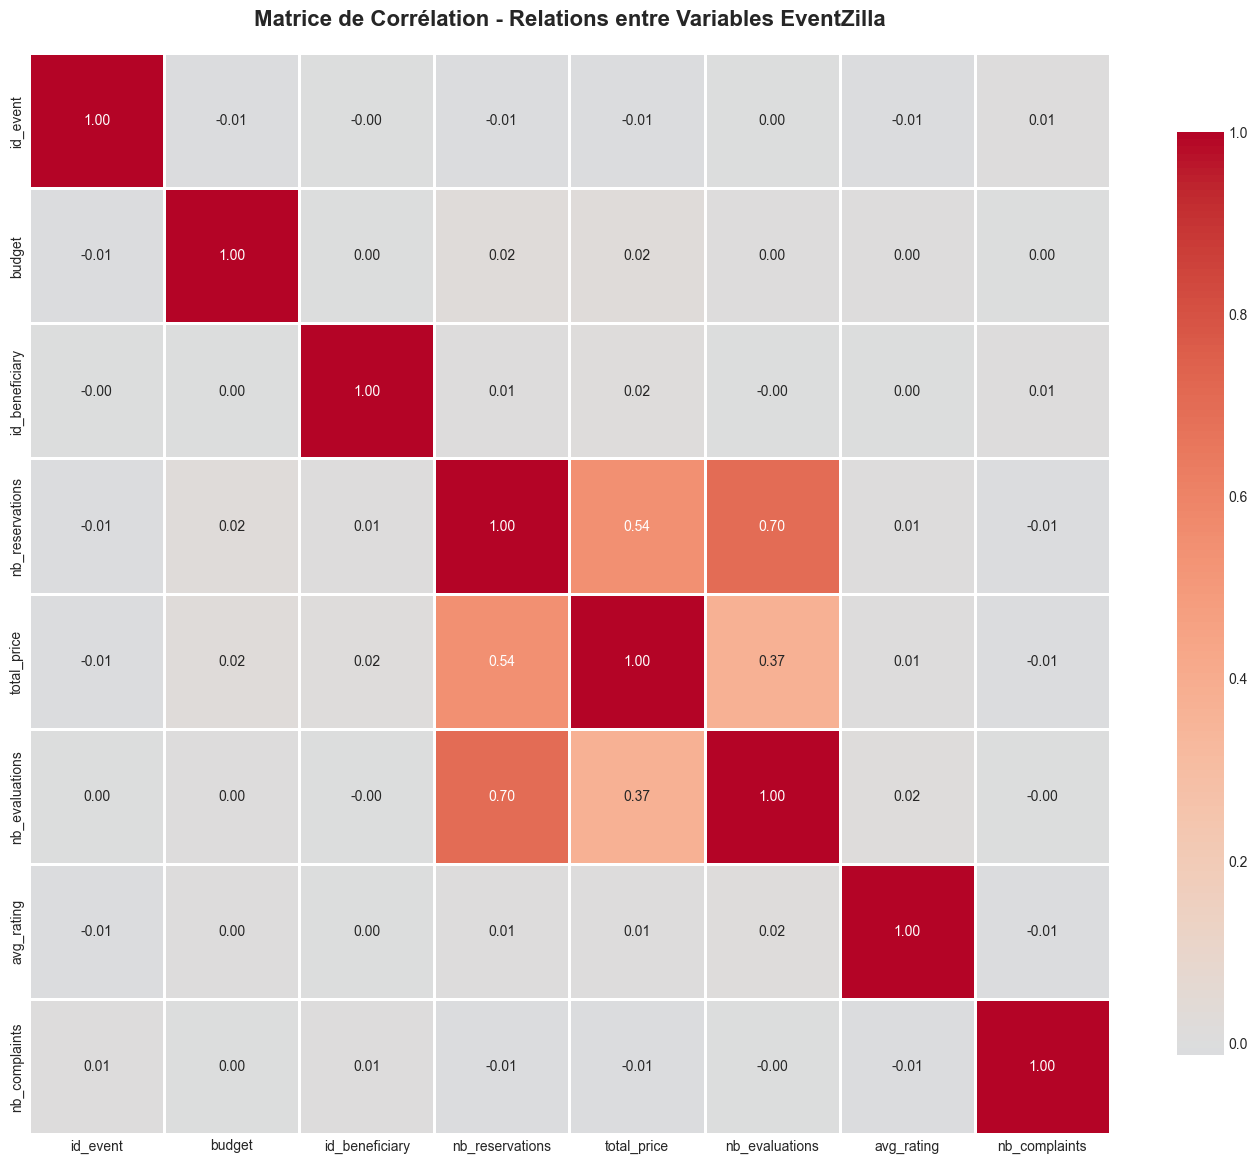


📊 Matrice de corrélation (valeurs numériques) :
                 id_event  budget  id_beneficiary  nb_reservations  total_price  nb_evaluations  avg_rating  nb_complaints
id_event            1.000  -0.007          -0.004           -0.009       -0.011           0.002      -0.009          0.009
budget             -0.007   1.000           0.000            0.019        0.021           0.004       0.004          0.001
id_beneficiary     -0.004   0.000           1.000            0.008        0.017          -0.001       0.001          0.007
nb_reservations    -0.009   0.019           0.008            1.000        0.542           0.703       0.008         -0.010
total_price        -0.011   0.021           0.017            0.542        1.000           0.373       0.008         -0.012
nb_evaluations      0.002   0.004          -0.001            0.703        0.373           1.000       0.015         -0.004
avg_rating         -0.009   0.004           0.001            0.008        0.008           

In [6]:
# Préparation des données pour la matrice de corrélation
# On va créer des métriques agrégées par fichier pour étudier les relations

print("📊 PRÉPARATION DES DONNÉES POUR LA MATRICE DE CORRÉLATION\n")

# Créer un DataFrame consolidé avec des métriques par événement
try:
    if 'event' in dataframes and 'reservation' in dataframes:
        # Métriques par événement
        event_metrics = dataframes['event'].copy()
        
        # Nombre de réservations par événement
        reservations_per_event = dataframes['reservation'].groupby('id_event').agg({
            'id_reservation': 'count',
            'final_price': 'sum'
        }).rename(columns={'id_reservation': 'nb_reservations', 'final_price': 'total_price'})
        
        event_metrics = event_metrics.merge(reservations_per_event, left_on='id_event', right_index=True, how='left')
        event_metrics['nb_reservations'] = event_metrics['nb_reservations'].fillna(0)
        event_metrics['total_price'] = event_metrics['total_price'].fillna(0)
        
        # Nombre d'évaluations par événement (via réservations)
        if 'evaluation' in dataframes:
            eval_per_reservation = dataframes['evaluation'].groupby('id_reservation').size()
            reservations_with_eval = dataframes['reservation'][
                dataframes['reservation']['id_reservation'].isin(eval_per_reservation.index)
            ]
            eval_per_event = reservations_with_eval.groupby('id_event').size()
            event_metrics = event_metrics.merge(
                pd.DataFrame({'nb_evaluations': eval_per_event}),
                left_on='id_event',
                right_index=True,
                how='left'
            )
            event_metrics['nb_evaluations'] = event_metrics['nb_evaluations'].fillna(0)
        
        # Note moyenne par événement
        if 'evaluation' in dataframes and 'reservation' in dataframes:
            eval_with_event = dataframes['evaluation'].merge(
                dataframes['reservation'][['id_reservation', 'id_event']],
                on='id_reservation',
                how='left'
            )
            avg_rating_per_event = eval_with_event.groupby('id_event')['rating'].mean()
            event_metrics = event_metrics.merge(
                pd.DataFrame({'avg_rating': avg_rating_per_event}),
                left_on='id_event',
                right_index=True,
                how='left'
            )
        
        # Nombre de réclamations par bénéficiaire
        if 'complaint' in dataframes:
            complaints_per_beneficiary = dataframes['complaint'].groupby('id_beneficiary').size()
            event_metrics = event_metrics.merge(
                pd.DataFrame({'nb_complaints': complaints_per_beneficiary}),
                left_on='id_beneficiary',
                right_index=True,
                how='left'
            )
            event_metrics['nb_complaints'] = event_metrics['nb_complaints'].fillna(0)
        
        # Sélectionner les colonnes numériques pour la corrélation
        numeric_cols = event_metrics.select_dtypes(include=[np.number]).columns.tolist()
        
        # Filtrer les colonnes qui ont au moins 2 valeurs non nulles
        numeric_cols = [col for col in numeric_cols if event_metrics[col].notna().sum() >= 2]
        
        if len(numeric_cols) > 1:
            # Créer la matrice de corrélation
            correlation_matrix = event_metrics[numeric_cols].corr()
            
            # Visualisation
            plt.figure(figsize=(14, 12))
            sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                        square=True, linewidths=1, cbar_kws={"shrink": 0.8})
            plt.title('Matrice de Corrélation - Relations entre Variables EventZilla', 
                      fontsize=16, fontweight='bold', pad=20)
            plt.tight_layout()
            plt.show()
            
            print("\n📊 Matrice de corrélation (valeurs numériques) :")
            print(correlation_matrix.round(3).to_string())
            
            # Interprétation des corrélations fortes
            print("\n💡 INTERPRÉTATION DES CORRÉLATIONS FORTES (|r| > 0.5) :")
            found_strong = False
            for i in range(len(correlation_matrix.columns)):
                for j in range(i+1, len(correlation_matrix.columns)):
                    corr_value = correlation_matrix.iloc[i, j]
                    if abs(corr_value) > 0.5 and not np.isnan(corr_value):
                        col1 = correlation_matrix.columns[i]
                        col2 = correlation_matrix.columns[j]
                        direction = "positive" if corr_value > 0 else "négative"
                        print(f"   - {col1} ↔ {col2} : {corr_value:.3f} (corrélation {direction} forte)")
                        found_strong = True
            if not found_strong:
                print("   ℹ️  Aucune corrélation forte (|r| > 0.5) détectée")
            else:
                print("\n   📌 Lignes d'interprétation :")
                print("   • nb_reservations ↔ total_price : plus un événement a de réservations, plus le montant total (total_price) est élevé — cohérent avec le volume de services réservés.")
                print("   • nb_reservations ↔ nb_evaluations : plus un événement a de réservations, plus il reçoit d'évaluations — les colonnes sont fortement corrélées (taux de retour client).")
                print("   • total_price et nb_evaluations sont aussi liés (r ≈ 0.37) : plus de CA par événement s'accompagne souvent de plus d'évaluations.")
        else:
            print("⚠️  Pas assez de colonnes numériques pour créer une matrice de corrélation")
    else:
        print("⚠️  Impossible de créer la matrice de corrélation : fichiers manquants")
except Exception as e:
    print(f"❌ Erreur lors de la création de la matrice de corrélation : {str(e)}")
    import traceback
    traceback.print_exc()


## 6. Visualisations exploratoires et interprétations métier (alignement DataMarketingRanimFinal)

Cette section ajoute des **graphiques de distribution** et des **interprétations courtes** liées aux objectifs métiers du document **DataMarketingRanimFinal** : nombre de réservations, taux de conversion, panier moyen, acquisition de bénéficiaires, dépenses marketing, types d’événements et satisfaction.

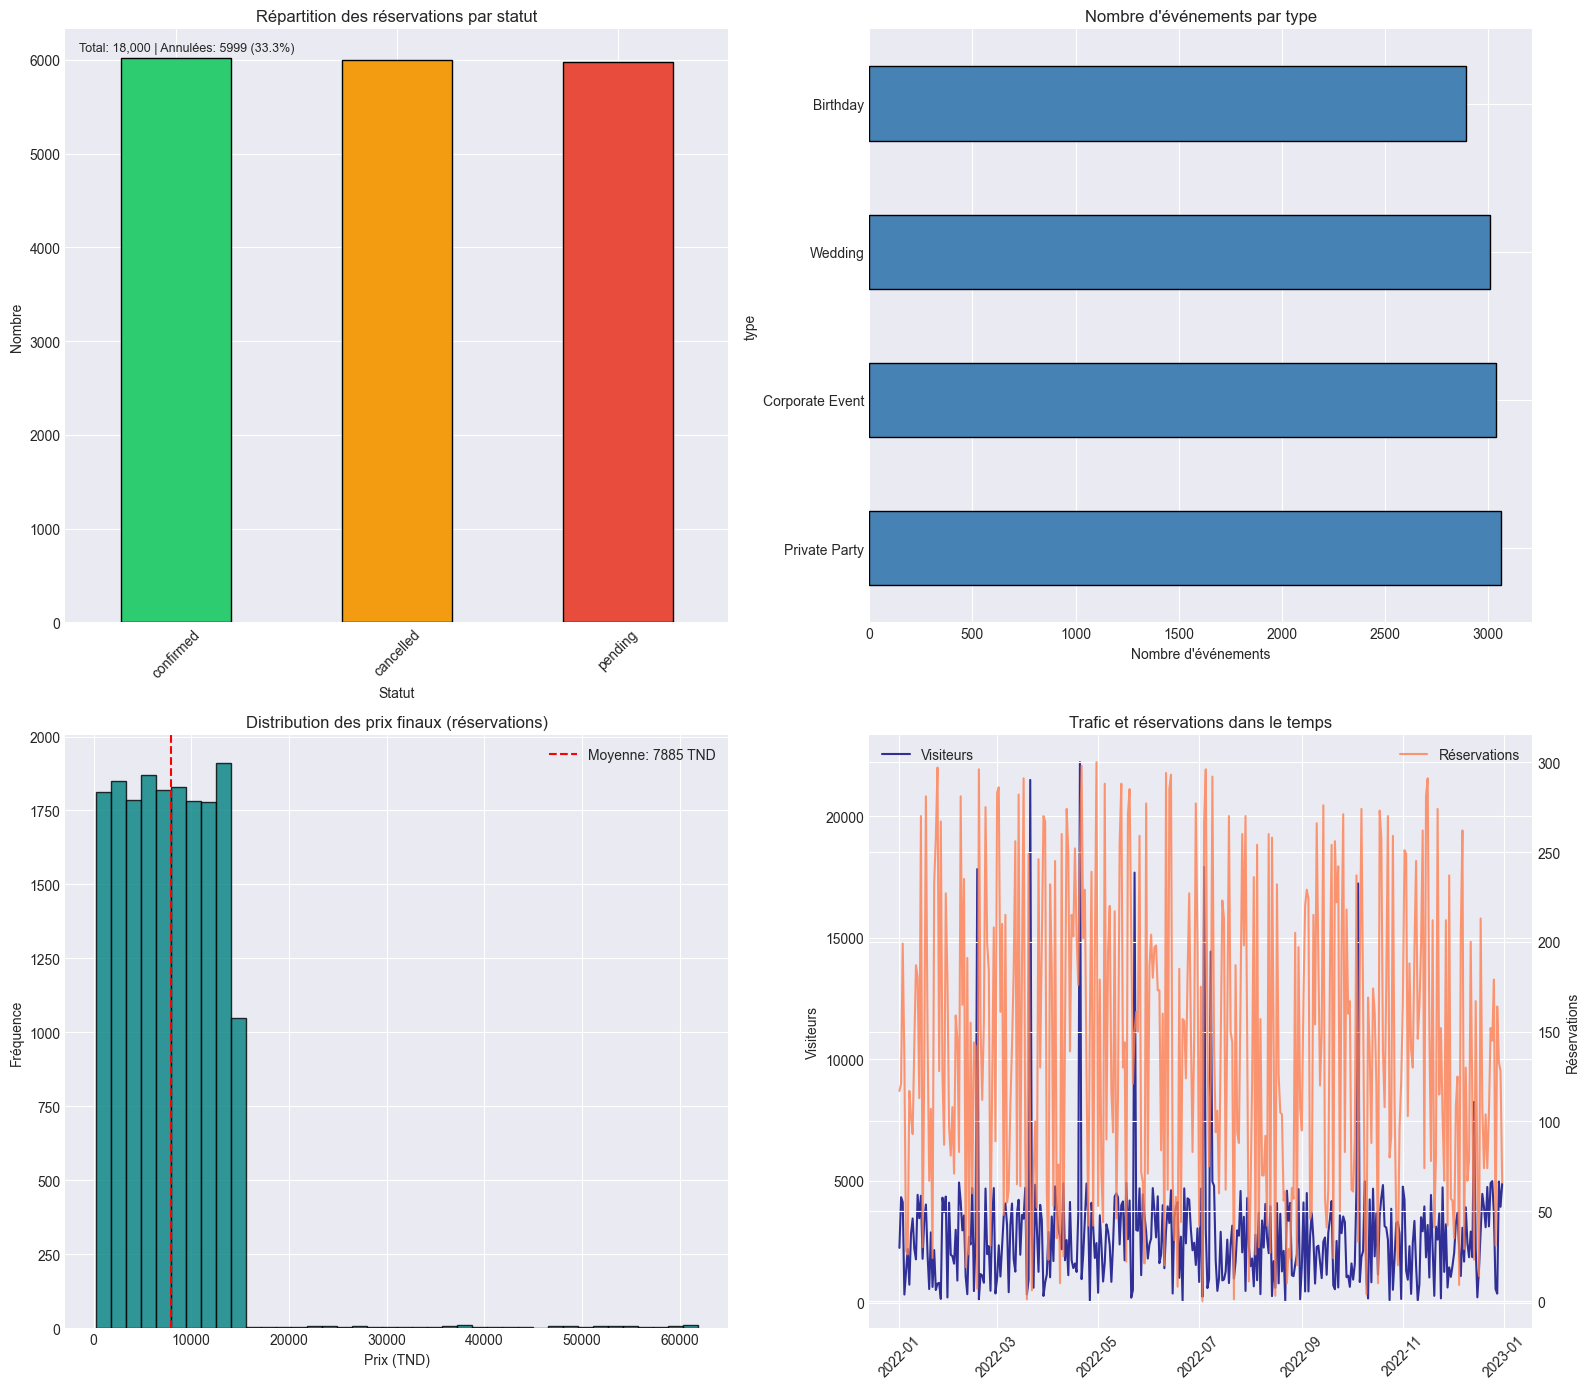

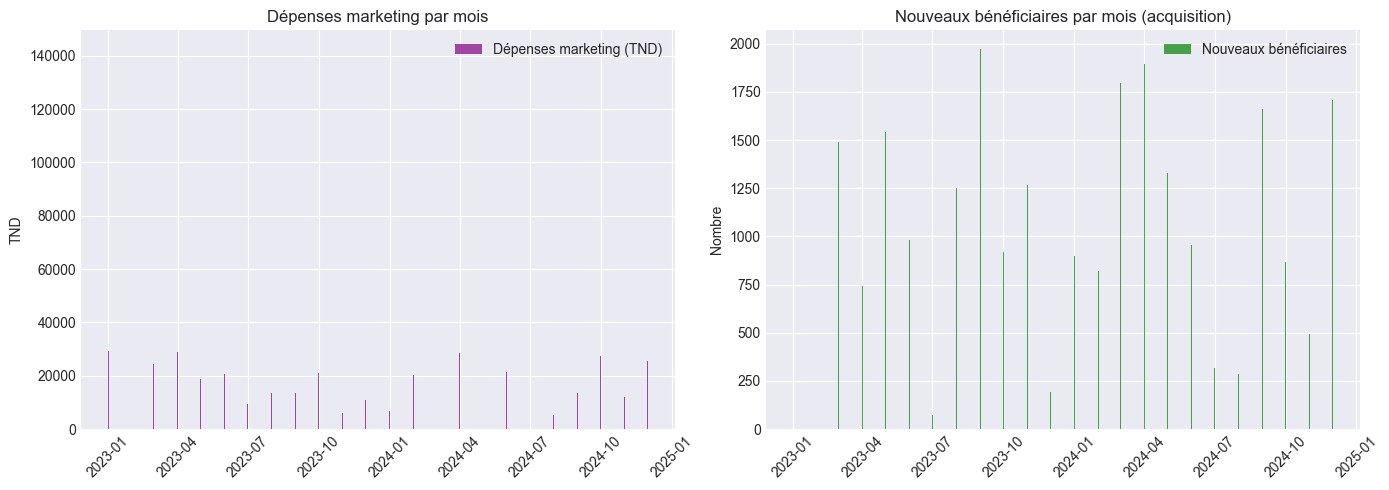

Interprétation métier (DataMarketingRanimFinal): CAC indicatif = Dépenses marketing totales / Nouveaux bénéficiaires = 22 TND par nouveau bénéficiaire.


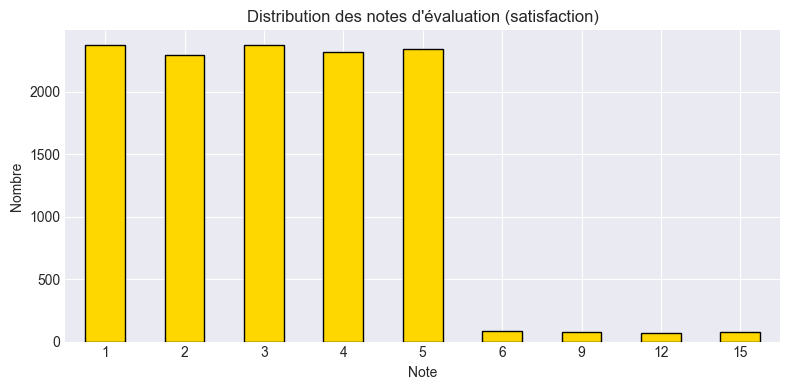


--- Interprétations liées aux objectifs métier (DataMarketingRanimFinal) ---
• Réservations: total 18000, confirmées 6024 (taux confirmation 33.5%). Panier moyen (confirmées): 9883 TND.
• Taux de conversion (global): réservations / visiteurs = 5.17%.
• Types d'événements les plus fréquents alimentent les décisions 'événements à promouvoir' (responsable marketing).
• Dépenses marketing et nouveaux bénéficiaires permettent de suivre le CAC et l'acquisition (objectifs marketing et financier).


In [7]:
# --- Graphiques exploratoires et interprétations métier (KPIs DataMarketingRanimFinal) ---
if len(dataframes) == 0:
    print("Charger d'abord les données (section 1).")
else:
    fig = plt.figure(figsize=(16, 14))
    
    # 1. Répartition des réservations par statut (KPI: nb réservations, taux annulation)
    ax1 = fig.add_subplot(2, 2, 1)
    if 'reservation' in dataframes:
        df_res = dataframes['reservation']
        status_counts = df_res['status'].value_counts()
        status_counts.plot(kind='bar', ax=ax1, color=['#2ecc71','#f39c12','#e74c3c'], edgecolor='black')
        ax1.set_title("Répartition des réservations par statut")
        ax1.set_xlabel("Statut"); ax1.set_ylabel("Nombre"); ax1.tick_params(axis='x', rotation=45)
        n_tot = len(df_res); n_canc = (df_res['status'] == 'cancelled').sum()
        ax1.text(0.02, 0.98, f"Total: {n_tot:,} | Annulées: {n_canc} ({100*n_canc/n_tot:.1f}%)", transform=ax1.transAxes, fontsize=9, verticalalignment='top')
    
    # 2. Distribution des types d'événements (objectif: événements à promouvoir)
    ax2 = fig.add_subplot(2, 2, 2)
    if 'event' in dataframes:
        dataframes['event']['type'].value_counts().plot(kind='barh', ax=ax2, color='steelblue', edgecolor='black')
        ax2.set_title("Nombre d'événements par type")
        ax2.set_xlabel("Nombre d'événements")
    
    # 3. Distribution du prix final des réservations (KPI: panier moyen)
    ax3 = fig.add_subplot(2, 2, 3)
    if 'reservation' in dataframes:
        df_res = dataframes['reservation']
        prix = df_res['final_price'].dropna()
        prix = prix[(prix > 0) & (prix < prix.quantile(0.98))]
        ax3.hist(prix, bins=40, color='teal', edgecolor='black', alpha=0.8)
        ax3.axvline(prix.mean(), color='red', linestyle='--', label=f'Moyenne: {prix.mean():.0f} TND')
        ax3.set_title("Distribution des prix finaux (réservations)"); ax3.set_xlabel("Prix (TND)"); ax3.set_ylabel("Fréquence"); ax3.legend()
    
    # 4. Visiteurs et réservations dans le temps (KPI: taux de conversion, trafic)
    ax4 = fig.add_subplot(2, 2, 4)
    if 'visitors' in dataframes:
        df_v = dataframes['visitors'].copy()
        df_v['date_parsed'] = pd.to_datetime(df_v['date'], errors='coerce')
        df_v = df_v.dropna(subset=['date_parsed']).sort_values('date_parsed')
        ax4_twin = ax4.twinx()
        ax4.plot(df_v['date_parsed'], df_v['visitors'], color='navy', alpha=0.8, label='Visiteurs')
        ax4_twin.plot(df_v['date_parsed'], df_v['reservations'], color='coral', alpha=0.8, label='Réservations')
        ax4.set_ylabel("Visiteurs"); ax4_twin.set_ylabel("Réservations"); ax4.set_title("Trafic et réservations dans le temps")
        ax4.legend(loc='upper left'); ax4_twin.legend(loc='upper right')
        ax4.tick_params(axis='x', rotation=45)
    
    plt.tight_layout(); plt.show()
    
    # 5. Marketing: dépenses vs nouveaux bénéficiaires (KPI: CAC, acquisition)
    if 'marketing_spend' in dataframes:
        fig2, (ax5, ax6) = plt.subplots(1, 2, figsize=(14, 5))
        df_m = dataframes['marketing_spend']
        df_m['month_parsed'] = pd.to_datetime(df_m['month'] + '-01', errors='coerce')
        df_m = df_m.dropna(subset=['month_parsed']).sort_values('month_parsed')
        ax5.bar(df_m['month_parsed'], df_m['marketing_spend'], color='purple', alpha=0.7, label='Dépenses marketing (TND)')
        ax5.set_title("Dépenses marketing par mois"); ax5.set_ylabel("TND"); ax5.tick_params(axis='x', rotation=45); ax5.legend()
        ax6.bar(df_m['month_parsed'], df_m['new_beneficiaries'], color='green', alpha=0.7, label='Nouveaux bénéficiaires')
        ax6.set_title("Nouveaux bénéficiaires par mois (acquisition)"); ax6.set_ylabel("Nombre"); ax6.tick_params(axis='x', rotation=45); ax6.legend()
        plt.tight_layout(); plt.show()
        # CAC indicatif
        tot_spend = df_m['marketing_spend'].sum(); tot_new = df_m['new_beneficiaries'].sum()
        cac = tot_spend / tot_new if tot_new > 0 else None
        if cac is not None:
            print("Interprétation métier (DataMarketingRanimFinal): CAC indicatif = Dépenses marketing totales / Nouveaux bénéficiaires = {:.0f} TND par nouveau bénéficiaire.".format(cac))
    
    # 6. Notes d'évaluation (satisfaction, qualité prestataires)
    if 'evaluation' in dataframes:
        fig3, ax7 = plt.subplots(figsize=(8, 4))
        dataframes['evaluation']['rating'].value_counts().sort_index().plot(kind='bar', ax=ax7, color='gold', edgecolor='black')
        ax7.set_title("Distribution des notes d'évaluation (satisfaction)"); ax7.set_xlabel("Note"); ax7.set_ylabel("Nombre")
        ax7.tick_params(axis='x', rotation=0)
        plt.tight_layout(); plt.show()
    
    # Interprétations métier (résumé)
    print("\n--- Interprétations liées aux objectifs métier (DataMarketingRanimFinal) ---")
    if 'reservation' in dataframes:
        r = dataframes['reservation']; conf = (r['status'] == 'confirmed').sum(); tot = len(r)
        panier = r[r['status'] == 'confirmed']['final_price'].mean() if conf else 0
        print("• Réservations: total {}, confirmées {} (taux confirmation {:.1f}%). Panier moyen (confirmées): {:.0f} TND.".format(tot, conf, 100*conf/tot if tot else 0, panier))
    if 'visitors' in dataframes and 'reservation' in dataframes:
        v = dataframes['visitors']; nb_vis = v['visitors'].sum(); nb_res_jour = v['reservations'].sum()
        conv = 100 * nb_res_jour / nb_vis if nb_vis else 0
        print("• Taux de conversion (global): réservations / visiteurs = {:.2f}%.".format(conv))
    if 'event' in dataframes:
        print("• Types d'événements les plus fréquents alimentent les décisions 'événements à promouvoir' (responsable marketing).")
    print("• Dépenses marketing et nouveaux bénéficiaires permettent de suivre le CAC et l'acquisition (objectifs marketing et financier).")

## 7. Analyse des Cardinalités et Relations

Cette section présente chaque **relation logique entre deux tables** sous forme de **scénario métier** pour en faciliter la compréhension.

### Scénarios des relations logiques

- **CATEGORY ↔ EVENT** : La **catégorie** est le *type d'événement* créé par le bénéficiaire (ex. mariage, entreprise, anniversaire). Les événements utilisent des services dont la sous-catégorie appartient à une catégorie.

- **SUBCATEGORY ↔ SERVICE** : La **sous-catégorie** est le *type de service* offert par le prestataire (ex. lieu, traiteur, animation, décoration). Chaque service proposé est rattaché à une sous-catégorie.

- **BENEFICIARY → EVENT** : Le **bénéficiaire** (client) crée et organise des **événements**. Un même bénéficiaire peut organiser plusieurs événements.

- **EVENT → RESERVATION** : Un **événement** regroupe plusieurs **réservations** de services (salle, traiteur, DJ, etc.). Une réservation lie un événement à un service.

- **PROVIDER → SERVICE** : Le **prestataire** propose des **services**. Un prestataire peut proposer plusieurs services (dans une ou plusieurs sous-catégories).

- **RESERVATION → EVALUATION** : Une **réservation** peut être **évaluée** par le bénéficiaire (note après le service). Une réservation a au plus une évaluation.

- **BENEFICIARY / PROVIDER → COMPLAINT** : Un **bénéficiaire** peut déposer une **réclamation** à l'encontre d'un **prestataire** (liée à un service ou un événement).


In [8]:
print("📊 CHIFFRES CLÉS PAR RELATION (complément aux scénarios ci-dessus)\n")

# BENEFICIARY → EVENT
if 'beneficiary' in dataframes and 'event' in dataframes:
    events_per_beneficiary = dataframes['event'].groupby('id_beneficiary').size()
    print(f"BENEFICIARY → EVENT : {len(events_per_beneficiary):,} bénéficiaires avec événements | 1 à {events_per_beneficiary.max()} événements / bénéficiaire")

# EVENT → RESERVATION
if 'event' in dataframes and 'reservation' in dataframes:
    reservations_per_event = dataframes['reservation'].groupby('id_event').size()
    print(f"EVENT → RESERVATION : {len(reservations_per_event):,} événements avec réservations | 1 à {reservations_per_event.max()} réservations / événement")

# PROVIDER → SERVICE
if 'provider' in dataframes and 'service' in dataframes:
    services_per_provider = dataframes['service'].groupby('id_provider').size()
    print(f"PROVIDER → SERVICE : {len(services_per_provider):,} prestataires | 1 à {services_per_provider.max()} services / prestataire")

# CATEGORY → SUBCATEGORY → SERVICE
if 'category' in dataframes and 'subcategory' in dataframes and 'service' in dataframes:
    subcats_per_category = dataframes['subcategory'].groupby('id_category').size()
    services_per_subcat = dataframes['service'].groupby('id_subcategory').size()
    print(f"CATEGORY → SUBCATEGORY → SERVICE : {subcats_per_category.min()}-{subcats_per_category.max()} sous-catégories / catégorie | {services_per_subcat.min():,}-{services_per_subcat.max():,} services / sous-catégorie")

# RESERVATION → EVALUATION
if 'reservation' in dataframes and 'evaluation' in dataframes:
    evaluated = len(dataframes['evaluation']['id_reservation'].unique())
    all_res = len(dataframes['reservation'])
    print(f"RESERVATION → EVALUATION : {evaluated:,} réservations évaluées sur {all_res:,} ({evaluated/all_res*100:.1f}%)")

# BENEFICIARY → COMPLAINT
if 'beneficiary' in dataframes and 'complaint' in dataframes:
    complaints_per_beneficiary = dataframes['complaint'].groupby('id_beneficiary').size()
    print(f"BENEFICIARY → COMPLAINT : {len(complaints_per_beneficiary):,} bénéficiaires avec réclamations | 1 à {complaints_per_beneficiary.max()} réclamations / bénéficiaire")


📊 CHIFFRES CLÉS PAR RELATION (complément aux scénarios ci-dessus)

BENEFICIARY → EVENT : 4,557 bénéficiaires avec événements | 1 à 10 événements / bénéficiaire
EVENT → RESERVATION : 9,290 événements avec réservations | 1 à 9 réservations / événement
PROVIDER → SERVICE : 764 prestataires | 1 à 11 services / prestataire
CATEGORY → SUBCATEGORY → SERVICE : 1-2 sous-catégories / catégorie | 604-639 services / sous-catégorie
RESERVATION → EVALUATION : 8,786 réservations évaluées sur 18,000 (48.8%)
BENEFICIARY → COMPLAINT : 1,952 bénéficiaires avec réclamations | 1 à 5 réclamations / bénéficiaire


## 8. Résumé et Conclusions


In [9]:
print("\n" + "="*80)
print("📋 RÉSUMÉ DE L'ANALYSE EDA")
print("="*80)

print("\n✅ POINTS FORTS :")
print("   - Intégrité référentielle excellente (aucune valeur orpheline)")
print("   - Fichiers RESERVATION, CATEGORY, SUBCATEGORY, VISITORS sans valeurs manquantes")
print("   - Aucun doublon détecté dans les fichiers")
print("   - Structure de données cohérente et bien organisée")

print("\n⚠️  POINTS D'ATTENTION :")
print("   - Valeurs manquantes dans BENEFICIARY (email, phone, last_name)")
print("   - Valeurs manquantes dans SERVICE (price)")
print("   - Valeurs manquantes dans EVENT (budget)")
print("   - Valeurs aberrantes dans EVALUATION (rating > 5)")
print("   - Format incohérent dans MARKETING_SPEND (mois > 12)")

print("\n💡 RECOMMANDATIONS PRINCIPALES :")
print("   1. Imputer les valeurs manquantes selon les stratégies définies")
print("   2. Corriger les valeurs aberrantes (rating > 5)")
print("   3. Normaliser le format des dates dans MARKETING_SPEND")
print("   4. Utiliser le matching entre fichiers pour compléter les données manquantes")
print("   5. Mettre en place des validations à l'import pour éviter les erreurs futures")

print(f"\n✅ Analyse terminée le {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)



📋 RÉSUMÉ DE L'ANALYSE EDA

✅ POINTS FORTS :
   - Intégrité référentielle excellente (aucune valeur orpheline)
   - Fichiers RESERVATION, CATEGORY, SUBCATEGORY, VISITORS sans valeurs manquantes
   - Aucun doublon détecté dans les fichiers
   - Structure de données cohérente et bien organisée

⚠️  POINTS D'ATTENTION :
   - Valeurs manquantes dans BENEFICIARY (email, phone, last_name)
   - Valeurs manquantes dans SERVICE (price)
   - Valeurs manquantes dans EVENT (budget)
   - Valeurs aberrantes dans EVALUATION (rating > 5)
   - Format incohérent dans MARKETING_SPEND (mois > 12)

💡 RECOMMANDATIONS PRINCIPALES :
   1. Imputer les valeurs manquantes selon les stratégies définies
   2. Corriger les valeurs aberrantes (rating > 5)
   3. Normaliser le format des dates dans MARKETING_SPEND
   4. Utiliser le matching entre fichiers pour compléter les données manquantes
   5. Mettre en place des validations à l'import pour éviter les erreurs futures

✅ Analyse terminée le 2026-02-09 00:10:11
